# Camada GOLD - Viagens a Servico do Governo Federal (2025)

Este notebook le a camada **SILVER** (ja limpa e tipada pelo `2_transformar.py`)
e responde as 7 perguntas de negocio do projeto. Para cada uma: a consulta SQL,
a tabela com o resultado e um grafico.

**Parte 1 - Perguntas direto da camada Silver**
1. Os 5 orgaos com maior custo total.
2. Os 3 destinos com maior custo medio por viagem.
3. A viagem de maior duracao e o seu custo total.

**Parte 2 - Camada Gold agregada (JOIN + GROUP BY, como tabela e como VIEW)**
4. O tipo de pagamento com maior valor medio.
5. O meio de transporte mais usado nos trechos.
6. A UF de destino que aparece em mais trechos.
7. O orgao que mais pagou no total.

Fonte: Portal da Transparencia do Governo Federal (6 meses de 2025).

## Conexao com o banco

Reaproveitando o banco.py, que está na mesma pasta scripts/. As credenciais ficam no .env, na raiz do projeto, nenhuma senha aparece no código.

In [112]:
import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt

import banco  # banco.py está na mesma pasta deste notebook

warnings.filterwarnings("ignore")  # silencia o aviso do pandas sobre DBAPI2

conexao = banco.conectar()

# pasta onde os gráficos são salvos
PASTA_DOCS = os.path.join("..", "docs")
os.makedirs(PASTA_DOCS, exist_ok=True)


def consultar(sql):
    """Roda um SELECT e devolve o resultado como DataFrame do pandas."""
    return pd.read_sql(sql, conexao)


def reais(valor):
    """Formata um número como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f"{valor:,.2f}"
    return "R$ " + texto.replace(",", "X").replace(".", ",").replace("X", ".")


def salvar(nome):
    """Salva o gráfico atual em docs/ para reaproveitar no README."""
    plt.savefig(os.path.join(PASTA_DOCS, nome), dpi=120, bbox_inches="tight")


print("Conectado ao MySQL com sucesso.")

Conectado ao MySQL com sucesso.


---
## Pergunta 1 - Os 5 orgaos com maior custo total

Agrupado `silver_viagem` por `nome_orgao_superior` e somado o `valor_total`
(a coluna calculada na Silver: diarias + passagens + outros gastos - devolução).

In [113]:
SQL_Q1 = """
SELECT
    nome_orgao_superior      AS orgao,
    COUNT(*)                 AS qtd_viagens,
    SUM(valor_total)         AS custo_total,
    AVG(valor_total)         AS custo_medio
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5
"""

q1 = consultar(SQL_Q1)
display(q1.assign(
    custo_total=q1["custo_total"].apply(reais),
    custo_medio=q1["custo_medio"].apply(reais),
))

,orgao,qtd_viagens,custo_total,custo_medio
0,Ministério da Justiça e Segurança Pública,75742,"R$ 486.933.121,65","R$ 6.428,84"
1,Ministério da Defesa,61912,"R$ 156.070.304,49","R$ 2.520,84"
2,Ministério da Educação,65295,"R$ 111.291.349,34","R$ 1.704,44"
3,Ministério do Meio Ambiente e Mudança do Clima,19413,"R$ 49.697.710,16","R$ 2.560,02"
4,Ministério da Previdência Social,8190,"R$ 40.417.309,06","R$ 4.934,96"


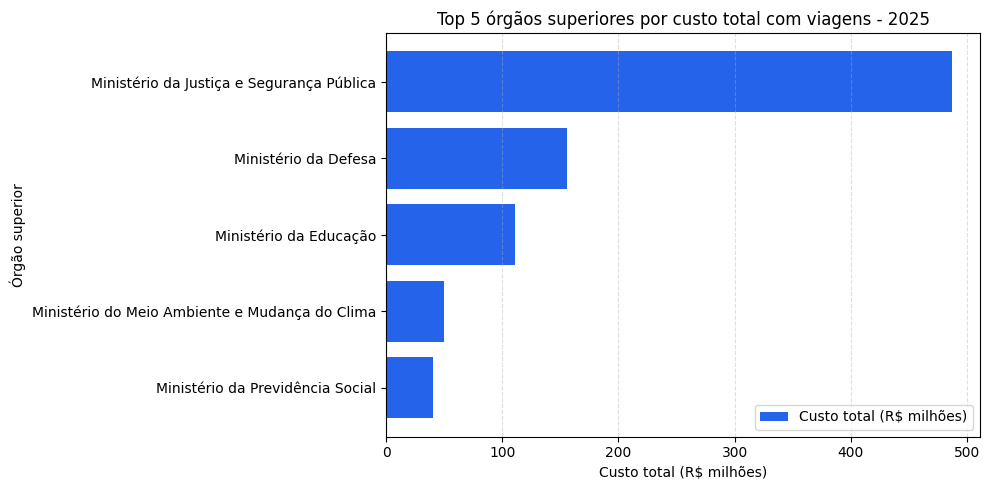

In [114]:
plt.figure(figsize=(10, 5))
# invertido a ordem para o maior ficar no topo do grafico horizontal
dados = q1.iloc[::-1]
plt.barh(dados["orgao"], dados["custo_total"] / 1_000_000, color="#2563EB", label="Custo total (R$ milhões)")
plt.title("Top 5 órgãos superiores por custo total com viagens - 2025")
plt.xlabel("Custo total (R$ milhões)")
plt.ylabel("Órgão superior")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q1_orgaos_custo_total.png")
plt.show()

---
## Pergunta 2 - Os 3 destinos com maior custo medio por viagem

A coluna destinos da silver_viagem é texto livre, e uma viagem pode ter vários destinos na mesma célula. Por isso foi escolhido usar o destino que vem dos trechos, que é estruturado.

Deste modo apareceu outro problema: uma viagem tem vários trechos, então um JOIN direto contaria o valor_total da mesma viagem mais de uma vez e a média sairia inflada. Resolvido com um SELECT DISTINCT do par (destino, viagem) dentro da subconsulta, antes de calcular a média.

Também foi filtrado os destinos com pelo menos 30 viagens, usando HAVING. Sem esse corte, o topo do ranking fica ocupado por destinos que tiveram uma única viagem cara(outlier), não um padrão de gasto.

In [115]:
SQL_Q2 = """
SELECT
    CONCAT(d.destino_cidade, '/', d.destino_uf) AS destino,
    COUNT(*)                                    AS qtd_viagens,
    AVG(d.valor_total)                          AS custo_medio
FROM (
    SELECT DISTINCT
        t.destino_cidade,
        t.destino_uf,
        v.id_viagem,
        v.valor_total
    FROM silver_trecho t
    JOIN silver_viagem v ON v.id_viagem = t.id_viagem
    WHERE t.destino_cidade IS NOT NULL
      AND t.destino_uf     IS NOT NULL
) AS d
GROUP BY destino
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3
"""

q2 = consultar(SQL_Q2)
display(q2.assign(custo_medio=q2["custo_medio"].apply(reais)))

,destino,qtd_viagens,custo_medio
0,Monte Negro/Rondônia,98,"R$ 84.926,03"
1,Sananduva/Rio Grande do Sul,103,"R$ 78.792,23"
2,Nonoai/Rio Grande do Sul,117,"R$ 77.931,92"


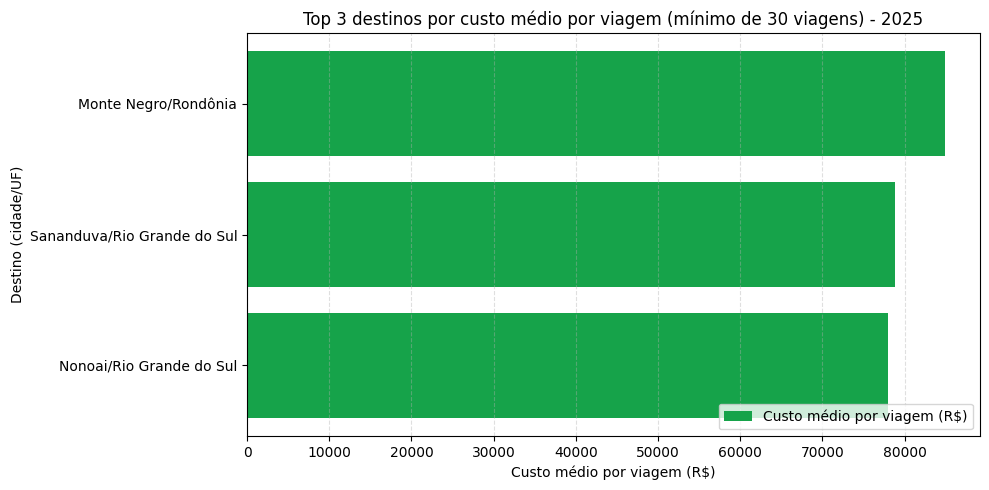

In [116]:
plt.figure(figsize=(10, 5))
dados = q2.iloc[::-1]
plt.barh(dados["destino"], dados["custo_medio"],color="#16A34A", label="Custo médio por viagem (R$)")
plt.title("Top 3 destinos por custo médio por viagem (mínimo de 30 viagens) - 2025")
plt.xlabel("Custo médio por viagem (R$)")
plt.ylabel("Destino (cidade/UF)")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q2_destinos_custo_medio.png")
plt.show()

---
## Pergunta 3 - A viagem de maior duracao e o seu custo total

A duracao_dias já vem calculada da Silver, como DATEDIFF(data_fim, data_inicio) + 1, contando também o dia de início. Trouxe as 10 maiores para dar contexto ao gráfico; a resposta da pergunta é a primeira linha.

In [117]:
SQL_Q3 = """
SELECT
    id_viagem,
    nome_orgao_superior,
    cargo,
    data_inicio,
    data_fim,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC, valor_total DESC
LIMIT 10
"""

q3 = consultar(SQL_Q3)
campea = q3.iloc[0]

contexto = consultar("SELECT AVG(duracao_dias) AS media FROM silver_viagem")
duracao_media = float(contexto.iloc[0]["media"])

print("RESPOSTA - viagem de maior duracao:")
print("  id_viagem   :", campea["id_viagem"])
print("  orgao       :", campea["nome_orgao_superior"])
print("  periodo     :", campea["data_inicio"], "ate", campea["data_fim"])
print("  duracao     :", campea["duracao_dias"], "dias")
print("  custo total :", reais(campea["valor_total"]))
print(f"  (a duracao media de todas as viagens e de {duracao_media:.1f} dias)")

display(q3.assign(valor_total=q3["valor_total"].apply(reais)))

RESPOSTA - viagem de maior duracao:
  id_viagem   : 0000000000020699856
  orgao       : Ministério da Previdência Social
  periodo     : 2025-01-13 ate 2026-01-31
  duracao     : 384 dias
  custo total : R$ 0,00
  (a duracao media de todas as viagens e de 8.1 dias)


,id_viagem,nome_orgao_superior,cargo,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,TECNICO DO SEGURO SOCIAL,2025-01-13,2026-01-31,384,"R$ 0,00"
1,0000000000020793594,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-02,2026-01-15,379,"R$ 120.650,00"
2,0000000000020793492,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-11,2026-01-15,370,"R$ 113.382,50"
3,0000000000020774569,Ministério da Educação,PROFESSOR DO MAGISTERIO SUPERIOR,2025-02-26,2026-03-02,370,"R$ 0,00"
4,0000000000020592696,Ministério da Justiça e Segurança Pública,None,2025-01-01,2026-01-02,367,"R$ 159.044,90"
5,0000000000020685666,Ministério da Justiça e Segurança Pública,None,2025-01-01,2026-01-02,367,"R$ 124.312,50"
6,0000000000020732132,Ministério da Educação,PROFESSOR DO MAGISTERIO SUPERIOR,2025-03-31,2026-03-31,366,"R$ 0,00"
7,0000000000020589962,Ministério da Educação,PROFESSOR DO MAGISTERIO SUPERIOR,2025-02-23,2026-02-23,366,"R$ 0,00"
8,0000000000020557147,Ministério da Justiça e Segurança Pública,None,2025-01-01,2025-12-31,365,"R$ 216.729,36"
9,0000000000020649880,Ministério da Justiça e Segurança Pública,None,2025-01-01,2025-12-31,365,"R$ 207.220,14"


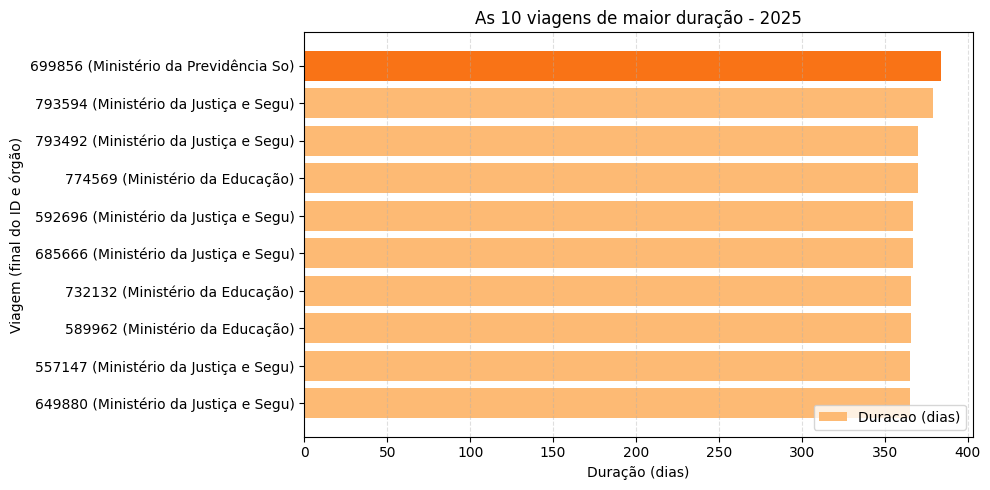

In [118]:
plt.figure(figsize=(10, 5))
dados = q3.iloc[::-1]
rotulos = dados["id_viagem"].astype(str).str[-6:] + " (" + dados["nome_orgao_superior"].str[:28] + ")"
cores = ["#F97316" if i == len(dados) - 1 else "#FDBA74" for i in range(len(dados))]
plt.barh(rotulos, dados["duracao_dias"], color=cores, label="Duracao (dias)")
plt.title("As 10 viagens de maior duração - 2025")
plt.xlabel("Duração (dias)")
plt.ylabel("Viagem (final do ID e órgão)")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q3_viagens_duracao.png")
plt.show()

---
# Camada GOLD agregada

Na arquitetura Medallion, a camada Gold guarda tabelas já agregadas, prontas para o negócio consumir sem repetir o processamento.

Criado a gold_orgao_gastos juntando (JOIN) a silver_viagem com a silver_pagamento pela chave id_viagem e agrupando (GROUP BY) por órgão superior. A mesma consulta é materializada de duas formas, como pede o enunciado:

tabela gold_orgao_gastos, criada com CREATE TABLE ... AS SELECT ... — o resultado fica congelado e a leitura é rápida;
VIEW vw_gold_orgao_gastos — é recalculada a cada consulta, então nunca fica desatualizada.

In [119]:
SQL_GOLD = """
SELECT
    v.nome_orgao_superior        AS orgao,
    COUNT(DISTINCT v.id_viagem)  AS qtd_viagens,
    COUNT(*)                     AS qtd_pagamentos,
    SUM(p.valor)                 AS total_pago,
    AVG(p.valor)                 AS ticket_medio
FROM silver_viagem v
JOIN silver_pagamento p ON p.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior
"""

banco.executar(conexao, "DROP TABLE IF EXISTS gold_orgao_gastos")
banco.executar(conexao, f"CREATE TABLE gold_orgao_gastos AS {SQL_GOLD}")
print("Tabela gold_orgao_gastos criada.")

banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_orgao_gastos")
banco.executar(conexao, f"CREATE VIEW vw_gold_orgao_gastos AS {SQL_GOLD}")
print("VIEW vw_gold_orgao_gastos criada.")

gold = consultar("SELECT * FROM gold_orgao_gastos ORDER BY total_pago DESC")
print("Linhas na camada Gold:", len(gold))
display(gold.head(10).assign(
    total_pago=gold.head(10)["total_pago"].apply(reais),
    ticket_medio=gold.head(10)["ticket_medio"].apply(reais),
))

Tabela gold_orgao_gastos criada.
VIEW vw_gold_orgao_gastos criada.
Linhas na camada Gold: 35


,orgao,qtd_viagens,qtd_pagamentos,total_pago,ticket_medio
0,Ministério da Justiça e Segurança Pública,75633,175814,"R$ 488.831.110,61","R$ 2.780,39"
1,Ministério da Defesa,61388,93574,"R$ 156.549.767,91","R$ 1.673,00"
2,Ministério da Educação,60011,93340,"R$ 111.897.434,35","R$ 1.198,82"
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,"R$ 50.123.043,80","R$ 1.899,03"
4,Ministério da Previdência Social,7911,20106,"R$ 40.659.494,63","R$ 2.022,26"
5,Ministério da Saúde,8185,18914,"R$ 39.517.918,03","R$ 2.089,35"
6,Ministério da Fazenda,11760,23613,"R$ 32.666.017,41","R$ 1.383,39"
7,Ministério dos Povos Indígenas,5046,10618,"R$ 26.441.142,20","R$ 2.490,22"
8,Ministério das Relações Exteriores,1944,3757,"R$ 25.724.337,16","R$ 6.847,04"
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,"R$ 22.171.683,47","R$ 1.673,71"


---
## Pergunta 4 - O tipo de pagamento com maior valor medio

Valor médio e valor total são diferentes: um tipo de pagamento pode ter o maior ticket médio e ainda assim não ser o que mais consome orçamento, se for raro. Por isso deixei as duas colunas na tabela.

In [120]:
SQL_Q4 = """
SELECT
    tipo_pagamento,
    COUNT(*)     AS qtd_pagamentos,
    AVG(valor)   AS valor_medio,
    SUM(valor)   AS valor_total
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC
"""

q4 = consultar(SQL_Q4)
print("RESPOSTA - maior valor medio:", q4.iloc[0]["tipo_pagamento"],
      "com", reais(q4.iloc[0]["valor_medio"]), "por pagamento")
display(q4.assign(
    valor_medio=q4["valor_medio"].apply(reais),
    valor_total=q4["valor_total"].apply(reais),
))

RESPOSTA - maior valor medio: DIÁRIAS com R$ 2.078,28 por pagamento


,tipo_pagamento,qtd_pagamentos,valor_medio,valor_total
0,DIÁRIAS,401463,"R$ 2.078,28","R$ 834.352.643,52"
1,PASSAGEM,188985,"R$ 1.878,34","R$ 354.978.915,13"
2,Serviço correlato: seguro,4894,"R$ 447,51","R$ 2.190.136,71"
3,RESTITUIÇÃO,11574,"R$ 245,70","R$ 2.843.762,01"


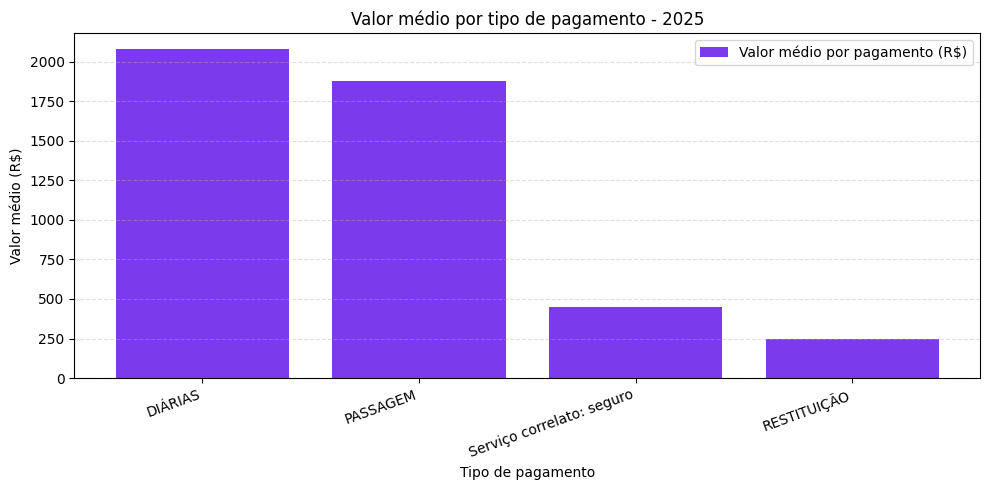

In [121]:
plt.figure(figsize=(10, 5))
plt.bar(q4["tipo_pagamento"], q4["valor_medio"], color="#7C3AED", label="Valor médio por pagamento (R$)")
plt.title("Valor médio por tipo de pagamento - 2025")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q4_tipo_pagamento.png")
plt.show()

---
## Pergunta 5 - O meio de transporte mais usado nos trechos

A propria fonte traz a categoria `Invalido` entre os meios de transporte.
Não removido: a camada Silver preserva o que existe na origem, e apontar o volume
dessa categoria e informacao util para o orgao melhorar o preenchimento.

In [122]:
SQL_Q5 = """
SELECT
    meio_transporte,
    COUNT(*) AS qtd_trechos
FROM silver_trecho
WHERE meio_transporte IS NOT NULL
GROUP BY meio_transporte
ORDER BY qtd_trechos DESC
"""

q5 = consultar(SQL_Q5)
total = q5["qtd_trechos"].sum()
q5["participacao_%"] = (q5["qtd_trechos"] / total * 100).round(1)
print("RESPOSTA - meio de transporte mais usado:", q5.iloc[0]["meio_transporte"],
      f"({q5.iloc[0]['qtd_trechos']} trechos, {q5.iloc[0]['participacao_%']}% do total)")
display(q5)

RESPOSTA - meio de transporte mais usado: Veículo Oficial (386424 trechos, 50.6% do total)


,meio_transporte,qtd_trechos,participacao_%
0,Veículo Oficial,386424,50.6
1,Aéreo,232666,30.5
2,Rodoviário,64970,8.5
3,Veículo Próprio,42846,5.6
4,Inválido,26659,3.5
5,Fluvial,8429,1.1
6,Ferroviário,874,0.1
7,Marítimo,481,0.1


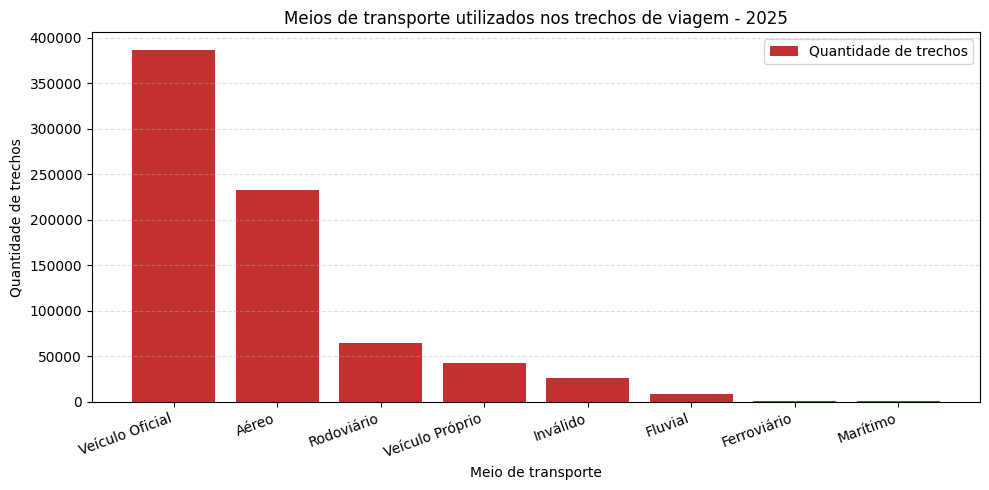

In [123]:
plt.figure(figsize=(10, 5))
plt.bar(q5["meio_transporte"], q5["qtd_trechos"], color="#c2312f", label="Quantidade de trechos")
plt.title("Meios de transporte utilizados nos trechos de viagem - 2025")
plt.xlabel("Meio de transporte")
plt.ylabel("Quantidade de trechos")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q5_meio_transporte.png")
plt.show()

---
## Pergunta 6 - A UF de destino que aparece em mais trechos

Contado os trechos por UF de destino e também a quantidade de viagens distintas, porque a razão entre os dois números diz se a UF costuma ser destino final ou escala.

In [124]:
SQL_Q6 = """
SELECT
    destino_uf,
    COUNT(*)                     AS qtd_trechos,
    COUNT(DISTINCT id_viagem)    AS qtd_viagens
FROM silver_trecho
WHERE destino_uf IS NOT NULL
GROUP BY destino_uf
ORDER BY qtd_trechos DESC
LIMIT 10
"""

q6 = consultar(SQL_Q6)
print("RESPOSTA - UF de destino mais frequente:", q6.iloc[0]["destino_uf"],
      f"({q6.iloc[0]['qtd_trechos']} trechos)")
display(q6)

RESPOSTA - UF de destino mais frequente: São Paulo (82722 trechos)


,destino_uf,qtd_trechos,qtd_viagens
0,São Paulo,82722,46392
1,Distrito Federal,79962,72297
2,Minas Gerais,50965,26891
3,Rio de Janeiro,44197,35050
4,Paraná,42603,22263
5,Pará,40044,18138
6,Rio Grande do Sul,38684,20104
7,Mato Grosso do Sul,30516,13332
8,Bahia,28375,14735
9,Pernambuco,28372,16637


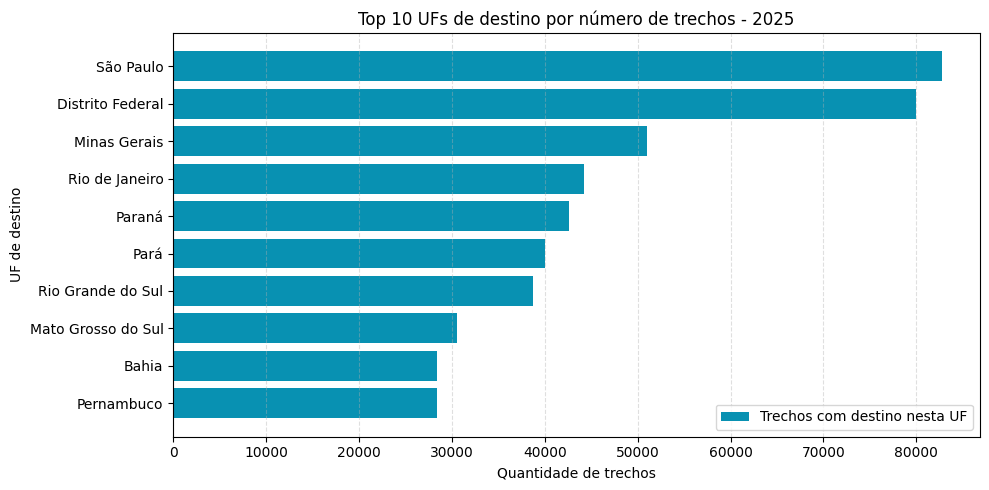

In [125]:
plt.figure(figsize=(10, 5))
dados = q6.iloc[::-1]
plt.barh(dados["destino_uf"], dados["qtd_trechos"], color="#0891B2", label="Trechos com destino nesta UF")
plt.title("Top 10 UFs de destino por número de trechos - 2025")
plt.xlabel("Quantidade de trechos")
plt.ylabel("UF de destino")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q6_uf_destino.png")
plt.show()

---
## Pergunta 7 - O órgão que mais pagou no total

Esta resposta sai direto da camada Gold criada acima, sem repetir o JOIN, é para isso que a camada agregada existe.

Vale comparar com a Pergunta 1. Lá o custo vem do que foi autorizado na viagem (silver_viagem.valor_total); aqui vem do que foi efetivamente pago (silver_pagamento.valor). Os cinco primeiros colocados são os mesmos nas duas consultas, mas os números não batem: a contagem de viagens cai de 75.742 para 75.633 no primeiro colocado, ou seja, 109 viagens não têm pagamento registrado dentro dos 6 meses da base.

In [126]:
SQL_Q7 = """
SELECT
    orgao,
    qtd_viagens,
    qtd_pagamentos,
    total_pago,
    ticket_medio
FROM gold_orgao_gastos
ORDER BY total_pago DESC
LIMIT 10
"""

q7 = consultar(SQL_Q7)
print("RESPOSTA - orgao que mais pagou no total:", q7.iloc[0]["orgao"],
      "com", reais(q7.iloc[0]["total_pago"]))
display(q7.assign(
    total_pago=q7["total_pago"].apply(reais),
    ticket_medio=q7["ticket_medio"].apply(reais),
))

RESPOSTA - orgao que mais pagou no total: Ministério da Justiça e Segurança Pública com R$ 488.831.110,61


,orgao,qtd_viagens,qtd_pagamentos,total_pago,ticket_medio
0,Ministério da Justiça e Segurança Pública,75633,175814,"R$ 488.831.110,61","R$ 2.780,39"
1,Ministério da Defesa,61388,93574,"R$ 156.549.767,91","R$ 1.673,00"
2,Ministério da Educação,60011,93340,"R$ 111.897.434,35","R$ 1.198,82"
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,"R$ 50.123.043,80","R$ 1.899,03"
4,Ministério da Previdência Social,7911,20106,"R$ 40.659.494,63","R$ 2.022,26"
5,Ministério da Saúde,8185,18914,"R$ 39.517.918,03","R$ 2.089,35"
6,Ministério da Fazenda,11760,23613,"R$ 32.666.017,41","R$ 1.383,39"
7,Ministério dos Povos Indígenas,5046,10618,"R$ 26.441.142,20","R$ 2.490,22"
8,Ministério das Relações Exteriores,1944,3757,"R$ 25.724.337,16","R$ 6.847,04"
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,"R$ 22.171.683,47","R$ 1.673,71"


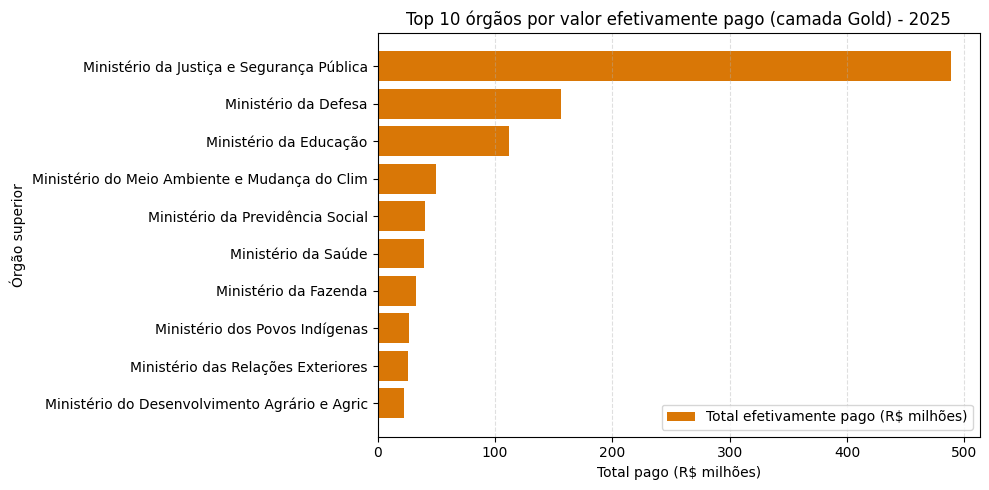

In [127]:
plt.figure(figsize=(10, 5))
dados = q7.head(10).iloc[::-1]
plt.barh(dados["orgao"].str[:45], dados["total_pago"] / 1_000_000, color="#D97706", label="Total efetivamente pago (R$ milhões)")
plt.title("Top 10 órgãos por valor efetivamente pago (camada Gold) - 2025")
plt.xlabel("Total pago (R$ milhões)")
plt.ylabel("Órgão superior")
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
salvar("q7_orgao_total_pago.png")
plt.show()

In [128]:
# Encerra a conexao com o banco
conexao.close()
print("Conexao encerrada.")

Conexao encerrada.
